In [18]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder, OrdinalEncoder, TargetEncoder,
    FunctionTransformer
)
from sklearn.pipeline import make_pipeline, make_union, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import (
    make_column_transformer, ColumnTransformer,
    make_column_selector,
    TransformedTargetRegressor
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn import set_config

import seaborn as sns
from itertools import cycle
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

set_config(transform_output="pandas")

seed = 14_02_2003
np.random.seed(seed)

import warnings
warnings.filterwarnings("ignore")

# Regresija cijene apartmana

**Student: Aleksa Ćetković sv77/2022**

## Eksplorativna analiza podataka

Skup podataka se sastoji od 6 kategoričkih, 3 numeričke kolone. Kolona "Sprat" sadrži i numericke i tekstualne labele pa je ona posebno enkodirana pretvarajuci sve vrijednosti u brojeve.

In [2]:
def read_json(path):
    df = pd.read_json(path)

    df['Sprat'] = (
        df['Sprat'].replace({
            "potkrovlje": -2,
            "suteren": -1,
            "nisko prizemlje": -0.5,
            "prizemlje": 0,
        })
    )
    
    df[['Slike', 'Cena', 'Kvadratura', 'Sobe', 'Sprat']] = (
        df[['Slike', 'Cena', 'Kvadratura', 'Sobe', 'Sprat']]
        .apply(pd.to_numeric, errors="coerce")
    )

    df[['Grad', 'Naziv', 'Prodavac', 'Uknjizen', 'Garaza', 'Parking']] = (
        df[['Grad', 'Naziv', 'Prodavac', 'Uknjizen', 'Garaza', 'Parking']]
        .astype("category")
    )

    return df.convert_dtypes()

df = read_json("data/train.json")
df

,Slike,Cena,Naziv,Grad,Kvadratura,Sobe,Sprat,Prodavac,Uknjizen,Garaza,Parking
0,9,150000,Crveni Krst Vračar,Beograd,48,2.0,7.0,Agencija,Da,Ne,Da
1,12,197200,Stevana Sremca,Niš,91,3.5,0.0,Agencija,Da,Da,Ne
2,16,215600,Petrovaradin,Novi Sad,98,4.0,1.0,Agencija,Da,Ne,Ne
3,10,126200,Trg kralja Aleksandra Ujedinitelja,Niš,72,3.0,2.0,Agencija,Da,Ne,Da
4,1,1,Ugao Partizanskih baza i Gutenbergove,Subotica,66,3.0,1.0,Investitor,Da,Ne,Ne
...,...,...,...,...,...,...,...,...,...,...,...
2091,8,55000,Teslino Naselje,Subotica,47,2.0,3.0,Agencija,Da,Ne,Ne
2092,20,340000,Lion,Beograd,106,3.5,1.0,Agencija,Da,Ne,Ne
2093,17,205000,Grbavica,Novi Sad,75,3.0,5.0,Agencija,Da,Ne,Ne
2094,16,150000,Gradske lokacije,Kruševac,72,3.0,-1.0,Agencija,Da,Ne,Ne


Kolona koju predvidjamo je "Cena", na grafiku ispod može se vidjeti da ima asimetričnu distribuciju. Kako bi poboljšali performanse modela koristićemo logaritam od stvarne vrijednosti za treniranje modela.

In [3]:
X = df.drop('Cena', axis=1)
y = df['Cena']

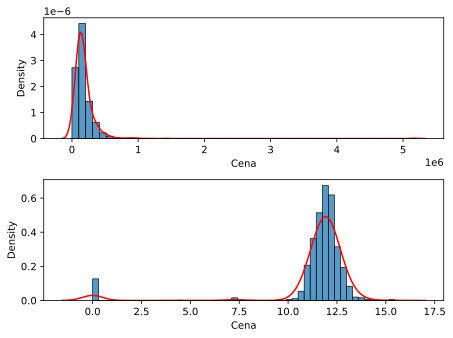

In [4]:
_, axes = plt.subplots(2, 1, layout="tight")

sns.histplot(y, bins=50, stat="density", ax=axes[0])
sns.kdeplot(y, ax=axes[0], color="red")

sns.histplot((log_y := np.log(y)), bins=50, stat="density", ax=axes[1])
sns.kdeplot(log_y, ax=axes[1], color="red");

In [5]:
y_transform = FunctionTransformer(np.log1p, np.expm1, feature_names_out="one-to-one")

In [6]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2096 entries, 0 to 2095
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Slike       2091 non-null   Int64   
 1   Cena        2096 non-null   Int64   
 2   Naziv       2096 non-null   category
 3   Grad        2096 non-null   category
 4   Kvadratura  2096 non-null   Int64   
 5   Sobe        2096 non-null   Float64 
 6   Sprat       2096 non-null   Float64 
 7   Prodavac    2096 non-null   category
 8   Uknjizen    2096 non-null   category
 9   Garaza      2096 non-null   category
 10  Parking     2096 non-null   category
dtypes: Float64(2), Int64(3), category(6)
memory usage: 128.9 KB


In [7]:
df.describe()

,Slike,Cena,Kvadratura,Sobe,Sprat
count,2091.0,2096.0,2096.0,2096.0,2096.0
mean,10.789096,181505.375954,66.849237,2.528626,2.346851
std,7.461864,233250.377886,32.722981,1.118574,3.374928
min,1.0,1.0,16.0,0.5,-2.0
25%,5.0,95140.25,45.0,2.0,1.0
50%,10.0,147000.0,61.0,2.5,2.0
75%,16.0,210000.0,79.0,3.0,3.0
max,74.0,5187757.0,330.0,20.0,100.0


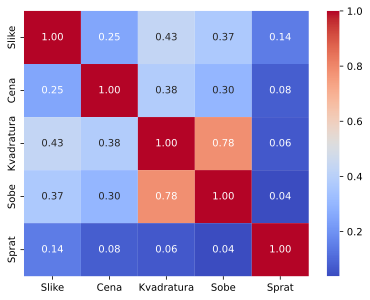

In [8]:
num_feat = df.select_dtypes("number")

corr = num_feat.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f");
num_feat = num_feat.drop('Cena', axis=1)

In [9]:
cat_feat = df.select_dtypes("category")
cat_feat.describe()

,Naziv,Grad,Prodavac,Uknjizen,Garaza,Parking
count,2096,2096,2096,2096,2096,2096
unique,695,5,3,2,2,2
top,Crveni Krst,Beograd,Agencija,Da,Ne,Ne
freq,84,753,1855,1383,1774,1713


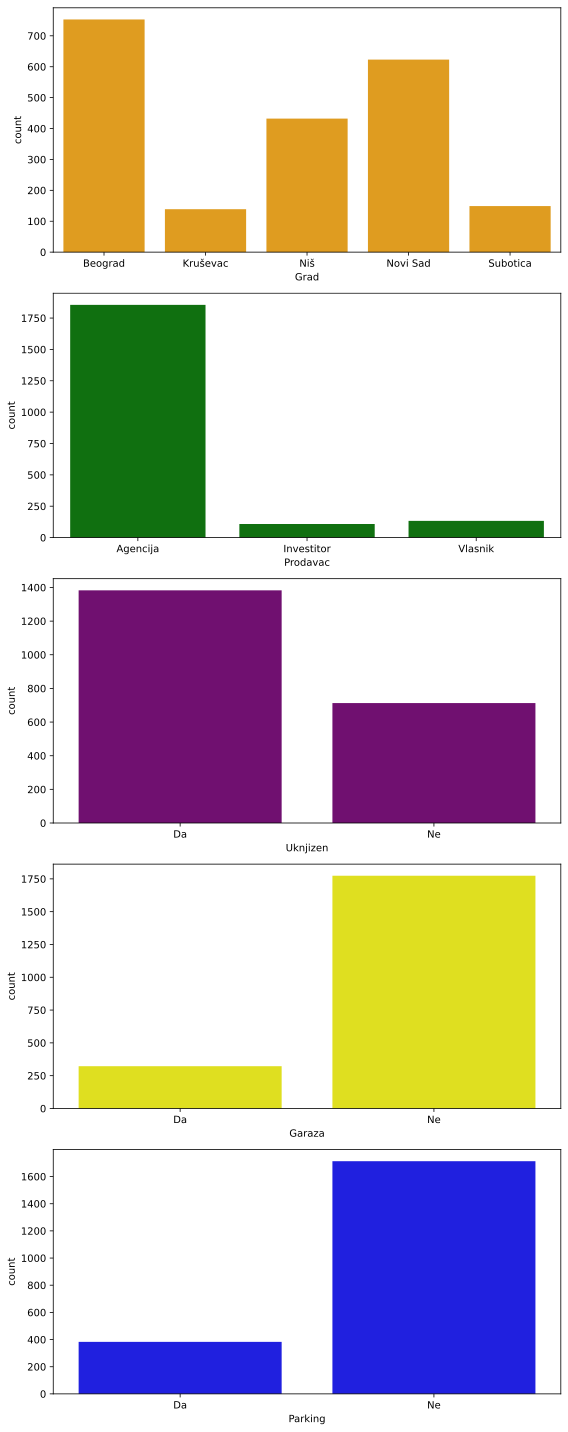

In [10]:
_small_cat_colnames = cat_feat.drop('Naziv', axis=1).columns

_, axes = plt.subplots(len(_small_cat_colnames), 1, figsize=(8, 4 * len(_small_cat_colnames)), layout="tight")

for ax, col, color in zip(axes, _small_cat_colnames, cycle(['orange', 'green', 'purple', 'yellow', 'blue', 'red'])):
    sns.countplot(data=df, x=col, ax=ax, color=color)

## Pretprocesiranje podataka

In [11]:

cat_preprocessor = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False),
)

cat_high_preprocessor = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    TargetEncoder(random_state=seed),
)

num_preprocessor = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

## Podela skupa podataka

Za sve isprobane modele (osim klasične linearne regresije) korišćena je unakrsna validacija (GridSearchCV), pri čemu je primenjena k-fold podela trening skupa na 5 delova (5-fold cross-validation). 

U svakom koraku, model se trenira na 4 dela podataka, dok se preostali deo koristi za validaciju. Ovaj proces se ponavlja 5 puta tako da svaki deo skupa jednom bude validacioni.

Na osnovu prosečne vrednosti metrike greške (MAPE) preko svih foldova biraju se optimalni hiperparametri, nakon čega se model ponovo trenira na celokupnom trening skupu sa izabranim parametrima.

## Isprobani algoritmi

Isprobano je više regresionih modela, kako parametarskih tako i neparametarskih.

Testirani su sledeći modeli:
- Linearna regresija (kao baseline model)
- Ridge regresija (regularizovana linearna regresija)
- Kernel Ridge regresija (nelinearni model zasnovan na kernel metodi)

In [12]:
lr_pre = make_column_transformer(
    (cat_preprocessor, ['Grad', 'Prodavac', 'Garaza', 'Uknjizen', 'Parking']),
    (num_preprocessor, ['Kvadratura', 'Sprat']),
)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)

lr = make_pipeline(
    lr_pre,
    TransformedTargetRegressor(
        LinearRegression(),
        transformer=y_transform,
    )
)

lr.fit(X_tr, y_tr);

In [13]:
lr_pred = lr.predict(X_te)
lr_score = mean_absolute_percentage_error(y_te, lr_pred)

pd.DataFrame({
    'MAPE': [f'{lr_score:.2f}%'],
})

,MAPE
0,2.29%


In [19]:
ridge_pre = make_column_transformer(
    (cat_preprocessor, ['Grad', 'Prodavac', 'Garaza', 'Uknjizen', 'Parking']),
    (num_preprocessor, ['Kvadratura', 'Slike', 'Sobe', 'Sprat']),
)

ridge = Pipeline([
    ("pre", ridge_pre),
    ("model", TransformedTargetRegressor(
        Ridge(random_state=seed),
        transformer=y_transform,
    ))
])

ridge_grid = {
    'model__regressor__alpha': [0, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

gcv_ridge = GridSearchCV(
    estimator= ridge,
    param_grid= ridge_grid,
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    return_train_score= True,
    n_jobs=-1,
    verbose= 1
)
gcv_ridge.fit(X, y);

Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [15]:
pd.DataFrame({
    'MAPE': [f'{abs(gcv_ridge.best_score_):.2f}%'],
    **{k.split("__")[-1]: v for k, v in gcv_ridge.best_params_.items()},
})

,MAPE,alpha
0,121.63%,1.0


In [20]:
kridge_pre = make_column_transformer(
    (cat_preprocessor, ['Grad', 'Prodavac', 'Garaza', 'Uknjizen', 'Parking']),
    (num_preprocessor, ['Kvadratura', 'Slike', 'Sobe', 'Sprat']),
)

kridge = Pipeline([
    ("pre", kridge_pre),
    ("model", TransformedTargetRegressor(
        regressor=KernelRidge(),
        transformer=y_transform,
    ))
])

kridge_grid = {
    "model__regressor__alpha": [0.1, 1, 10, 100],
    "model__regressor__kernel": ["rbf", "linear"],
    "model__regressor__gamma": [0.001, 0.01, 0.1],
}

gcv_kridge = GridSearchCV(
    estimator=kridge,
    param_grid=kridge_grid,
    cv=5,
    scoring="neg_mean_absolute_percentage_error",
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

gcv_kridge.fit(X, y);

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [17]:
pd.DataFrame({
    'MAPE': [f'{abs(gcv_kridge.best_score_):.2f}%'],
    **{k.split("__")[-1]: v for k, v in gcv_kridge.best_params_.items()},
})

,MAPE,alpha,gamma,kernel
0,10.97%,100,0.001,linear


## Odabrano rješenje

Kao konačni model izabran je **Kernel Ridge Regression (KRR)** jer je pokazao najbolje rezultate pri unakrsnoj validaciji.


## Reference

1. https://scikit-learn.org/stable/modules/preprocessing.html
2. https://miykael.github.io/blog/2023/03_scikit_advanced
3. https://github.com/AlexanderNixon/Machine-learning-reads
4. https://github.com/BindiChen/machine-learning/blob/main/data-analysis/001-pandad-pipe-function/pandas-pipe-to-improve-code-readability.ipynb
5. https://chat.openai.com (Pomoć oko brainstorminga, podesavanja parametara, generisanje grafika)